# 📈 Gold Stock Price Analysis & Prediction

**Mini Project — Data Cleaning • EDA • Feature Engineering • Machine Learning**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Load Dataset


In [2]:
raw = pd.read_csv("../data/gold_stock.csv")
print("Raw dataset shape:", raw.shape)
raw.head(6)


Raw dataset shape: 2,970 rows × 6 columns


Price,Close,High,Low,Open,Volume
Ticker,GOLD,GOLD,GOLD,GOLD,GOLD
Date,NaN,NaN,NaN,NaN,NaN
2014-03-17,4.711997032165527,4.85016815549002,4.425025639793251,4.425025639793251,68200
2014-03-18,5.048568248748779,5.278853682840762,4.694282757608514,4.711997099740122,135600
2014-03-19,4.959996223449707,5.1017102661133835,4.90685354191906,5.013138904980353,25600
2014-03-20,4.959996223449707,4.959996223449707,4.889493292947593,4.959996223449707,8200


## 2. Data Cleaning


In [3]:
df = raw.copy()
df["Date"] = df["Price"]
df = df.iloc[2:].copy()
for c in ["Close","High","Low","Open","Volume"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna().sort_values("Date").reset_index(drop=True)
df.head()


Rows before cleaning: 2,970
Metadata rows removed: 2
Clean market rows: 2,968
Missing values remaining: 57
Date range: 2014-03-17 to 2025-12-31


## 3. Exploratory Data Analysis


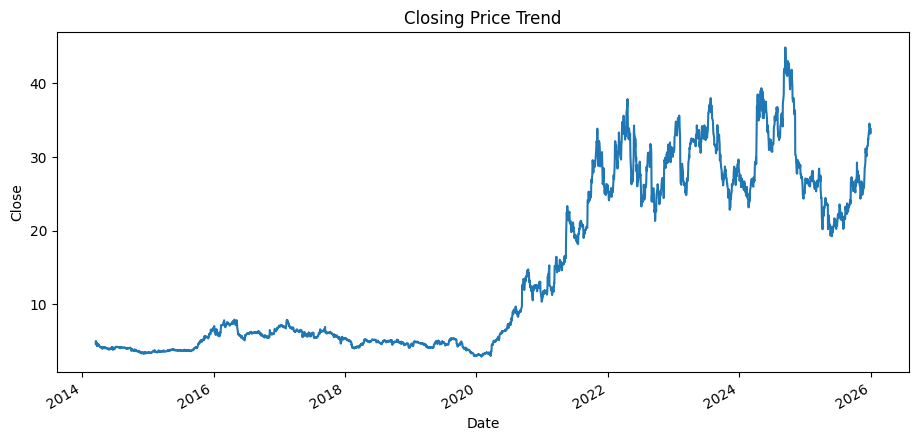

In [4]:
plt.figure(figsize=(11,5))
plt.plot(df["Date"], df["Close"] if "line"=="line" else df["C"])
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.show()


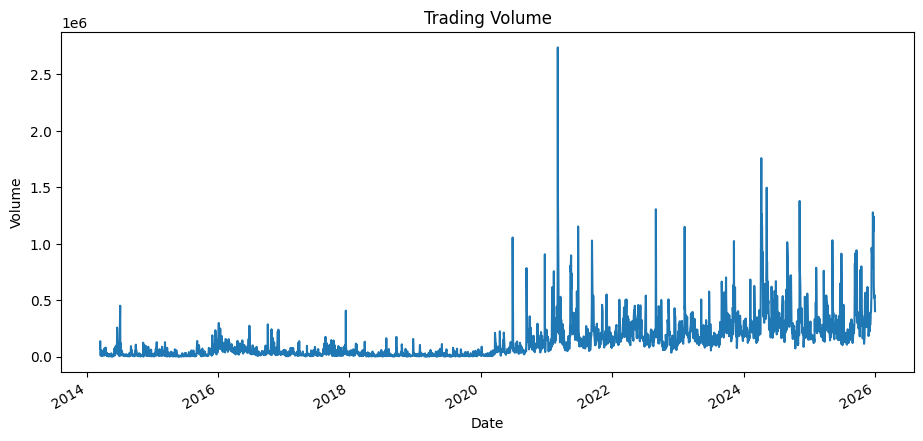

In [5]:
plt.figure(figsize=(11,5))
plt.plot(df["Date"], df["Volume"] if "line"=="line" else df["V"])
plt.title("Trading Volume")
plt.xlabel("Date")
plt.show()


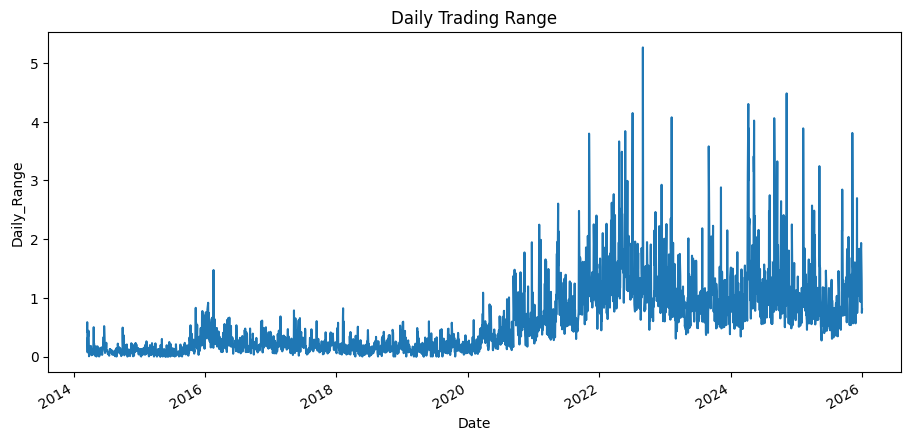

In [6]:
plt.figure(figsize=(11,5))
plt.plot(df["Date"], df["Daily_Range"] if "line"=="line" else df["D"])
plt.title("Daily Trading Range")
plt.xlabel("Date")
plt.show()


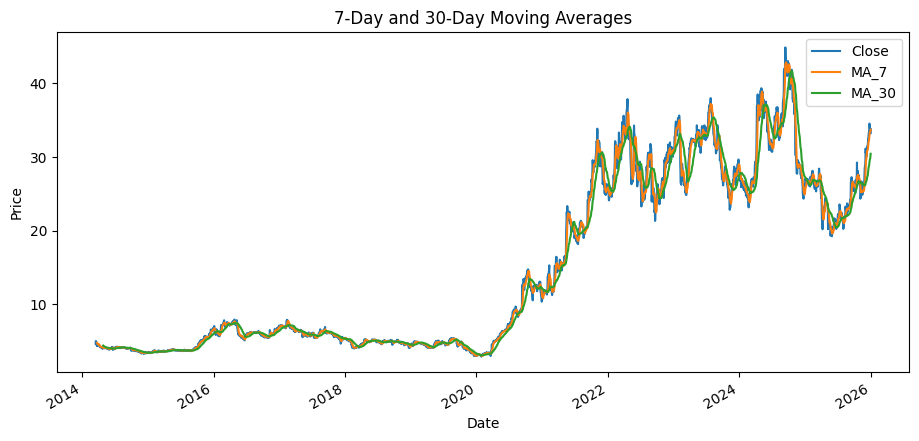

In [7]:
plt.figure(figsize=(11,5))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_7"], label="MA_7")
plt.plot(df["Date"], df["MA_30"], label="MA_30")
plt.title("7-Day and 30-Day Moving Averages")
plt.legend()
plt.show()


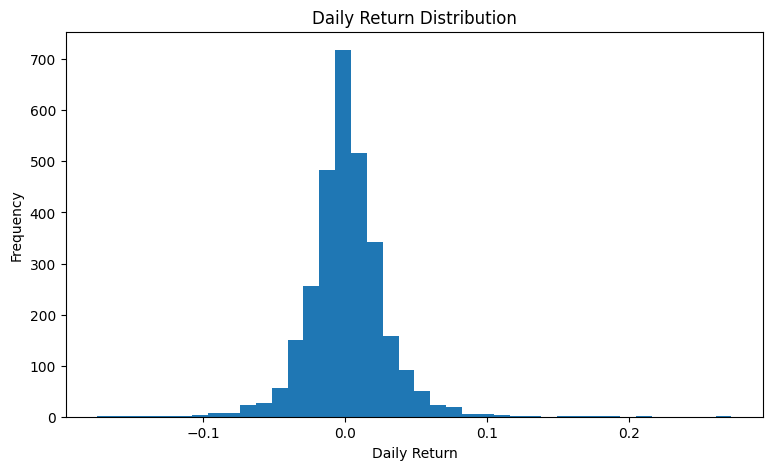

In [8]:
plt.figure(figsize=(9,5))
plt.hist(df["Return"].dropna(), bins=40)
plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


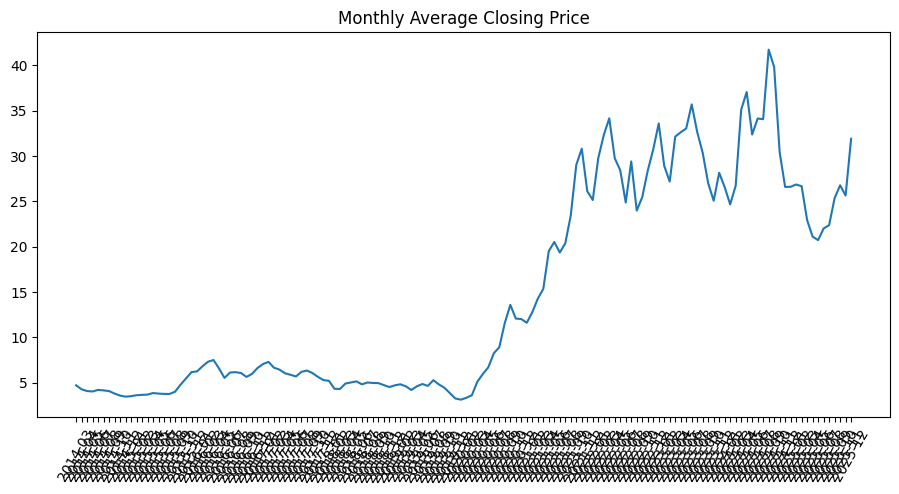

In [9]:
monthly = df.assign(Month=df["Date"].dt.to_period("M").astype(str)).groupby("Month")["Close"].mean()
plt.figure(figsize=(11,5))
plt.plot(monthly.index, monthly.values)
plt.title("Monthly Average Closing Price")
plt.xticks(rotation=60)
plt.show()


## 4. Feature Engineering & Machine Learning


In [10]:
df["Return"] = df["Close"].pct_change()
df["Daily_Range"] = df["High"] - df["Low"]
df["MA_7"] = df["Close"].rolling(7).mean()
df["MA_30"] = df["Close"].rolling(30).mean()
df["Volatility_7"] = df["Return"].rolling(7).std()
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Lag_1"] = df["Close"].shift(1)
df["Lag_7"] = df["Close"].shift(7)
df["Volume_MA_7"] = df["Volume"].rolling(7).mean()

features = ["Lag_1","Lag_7","MA_7","MA_30","Volatility_7","Volume_MA_7",
            "High","Low","Open","Volume","Daily_Range","Year","Month","DayOfWeek"]
model_df = df.dropna().copy()
split = int(len(model_df)*0.80)
X_train = model_df[features].iloc[:split]
X_test = model_df[features].iloc[split:]
y_train = model_df["Close"].iloc[:split]
y_test = model_df["Close"].iloc[split:]


Features: 14
Training rows: 2,351
Testing rows: 588
Model: Random Forest Regressor


In [11]:
model = RandomForestRegressor(
    n_estimators=120, max_depth=10,
    min_samples_leaf=2, random_state=42
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", mean_squared_error(y_test, predictions)**0.5)
print("R²:", r2_score(y_test, predictions))


Metric,Value
MAE,0.5570
RMSE,1.1127
R² Score,0.9606


## 5. Actual vs Predicted Closing Price


In [12]:
comparison = pd.DataFrame({
    "Actual Close": y_test.values,
    "Predicted Close": predictions
})
comparison.head(10)


Actual Close,Predicted Close
31.6492,31.6114
31.4589,31.5258
30.9152,31.3104
34.2949,34.1514
33.2076,33.7240
32.4374,32.7873
32.1294,32.2684
32.8633,32.6494
32.9844,32.9466
32.1924,32.4419


## 6. Key Findings & Conclusion

- Dataset covers **2014-03-17 to 2025-12-31**.
- Highest observed closing price: **44.8114** on **2024-09-13**.
- Lowest observed closing price: **2.9526** on **2020-01-28**.
- The 7-day and 30-day moving averages help identify short- and medium-term price trends.
- Random Forest achieved an **R² score of 0.9606** on the chronological test set.

**Note:** This project is for educational data-analysis purposes and should not be treated as financial advice.